In [1]:
import numpy as np

class GLM:
    def __init__(self, lr=0.01, epochs=100, batch_size=32, link='identity'):
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.link = link
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _link(self, z):
        if self.link == 'identity':
            return z
        elif self.link == 'sigmoid':
            return 1 / (1 + np.exp(-z))
        elif self.link == 'exp':
            return np.exp(z)

    def _loss(self, y, y_pred):
        if self.link == 'identity':
            return np.mean((y - y_pred) ** 2)
        elif self.link == 'sigmoid':
            eps = 1e-9
            return -np.mean(y*np.log(y_pred+eps)+(1-y)*np.log(1-y_pred+eps))
        elif self.link == 'exp':
            return np.mean(y_pred - y*np.log(y_pred+1e-9))

    def fit(self, X, y, verbose=False):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):

            # 🔀 Shuffle data every epoch
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]

                # Forward
                z = np.dot(X_batch, self.weights) + self.bias
                y_pred = self._link(z)

                # Gradients
                dz = y_pred - y_batch
                dw = (1 / len(X_batch)) * np.dot(X_batch.T, dz)
                db = (1 / len(X_batch)) * np.sum(dz)

                # Update
                self.weights -= self.lr * dw
                self.bias -= self.lr * db

            # Track loss (full data)
            full_pred = self._link(np.dot(X, self.weights) + self.bias)
            loss = self._loss(y, full_pred)
            self.loss_history.append(loss)

            if verbose and epoch % 10 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

In [5]:
import numpy as np

np.random.seed(42)

X = np.random.rand(100, 1) * 10   # values between 0–10
y = 3 * X.squeeze() + 2 + np.random.randn(100)  # add noise
model = GLM(lr=0.01, epochs=200, batch_size=16, link='identity')
model.fit(X, y, verbose=True)

print("Weights:", model.weights)
print("Bias:", model.bias)

Epoch 0, Loss: 3.4417
Epoch 10, Loss: 1.3589
Epoch 20, Loss: 1.1996
Epoch 30, Loss: 1.1221
Epoch 40, Loss: 0.9748
Epoch 50, Loss: 0.9214
Epoch 60, Loss: 0.8944
Epoch 70, Loss: 0.8645
Epoch 80, Loss: 0.8519
Epoch 90, Loss: 0.8489
Epoch 100, Loss: 0.8552
Epoch 110, Loss: 0.8221
Epoch 120, Loss: 0.8140
Epoch 130, Loss: 0.8117
Epoch 140, Loss: 0.8600
Epoch 150, Loss: 0.8188
Epoch 160, Loss: 0.8233
Epoch 170, Loss: 0.8219
Epoch 180, Loss: 0.8134
Epoch 190, Loss: 0.8070
Weights: [3.00752835]
Bias: 2.19045704087304


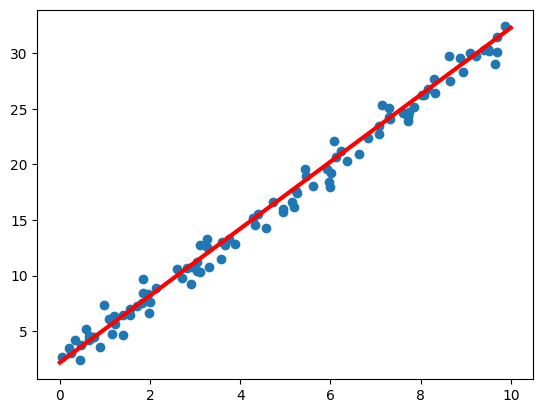

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
x_line = np.linspace(0,10,100)
y_line = model.weights*x_line + model.bias
plt.scatter(X,y)
plt.plot(x_line, y_line, color="red", label="Regression Line",linewidth=3)

In [19]:
import numpy as np

class GLM:
    def __init__(self, lr=0.01, epochs=100, batch_size=32, link='sigmoid'):
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.link = link
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _link(self, z):
        if self.link == 'identity':
            return z
        elif self.link == 'sigmoid':
            return 1 / (1 + np.exp(-z))
        elif self.link == 'exp':
            return np.exp(z)

    def _loss(self, y, y_pred):
        if self.link == 'identity':
            return np.mean((y - y_pred) ** 2)
        elif self.link == 'sigmoid':
            eps = 1e-9
            return -np.mean(y*np.log(y_pred+eps)+(1-y)*np.log(1-y_pred+eps))
        elif self.link == 'exp':
            return np.mean(y_pred - y*np.log(y_pred+1e-9))

    def fit(self, X, y, verbose=False):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):

            # 🔀 Shuffle data every epoch
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]

                # Forward
                z = np.dot(X_batch, self.weights) + self.bias
                y_pred = self._link(z)

                # Gradients
                dz = y_pred - y_batch
                dw = (1 / len(X_batch)) * np.dot(X_batch.T, dz)
                db = (1 / len(X_batch)) * np.sum(dz)

                # Update
                self.weights -= self.lr * dw
                self.bias -= self.lr * db

            # Track loss (full data)
            full_pred = self._link(np.dot(X, self.weights) + self.bias)
            loss = self._loss(y, full_pred)
            self.loss_history.append(loss)

            if verbose and epoch % 10 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

In [20]:
np.random.seed(42)

X = np.random.rand(100, 1) * 10
y = (X.squeeze() > 5).astype(int)
model = GLM(lr=0.1, epochs=200, batch_size=16, link='sigmoid')
model.fit(X, y, verbose=True)

preds = model._link(np.dot(X, model.weights) + model.bias)
print((preds > 0.5).astype(int))

Epoch 0, Loss: 0.5779
Epoch 10, Loss: 0.4144
Epoch 20, Loss: 0.3136
Epoch 30, Loss: 0.2546
Epoch 40, Loss: 0.2270
Epoch 50, Loss: 0.2121
Epoch 60, Loss: 0.1875
Epoch 70, Loss: 0.1745
Epoch 80, Loss: 0.1665
Epoch 90, Loss: 0.1570
Epoch 100, Loss: 0.1550
Epoch 110, Loss: 0.1452
Epoch 120, Loss: 0.1392
Epoch 130, Loss: 0.1358
Epoch 140, Loss: 0.1307
Epoch 150, Loss: 0.1272
Epoch 160, Loss: 0.1243
Epoch 170, Loss: 0.1234
Epoch 180, Loss: 0.1184
Epoch 190, Loss: 0.1188
[0 1 1 1 0 0 0 1 1 1 0 1 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 1 1 0 1 0 0 1 1 1 0
 0 1 0 0 1 0 1 0 1 0 1 1 0 1 1 1 1 1 1 0 0 0 0 0 0 1 0 0 1 0 1 0 1 1 0 0 1
 1 1 1 0 0 0 1 1 0 0 0 0 1 1 1 1 0 1 1 1 1 1 1 0 0 0]


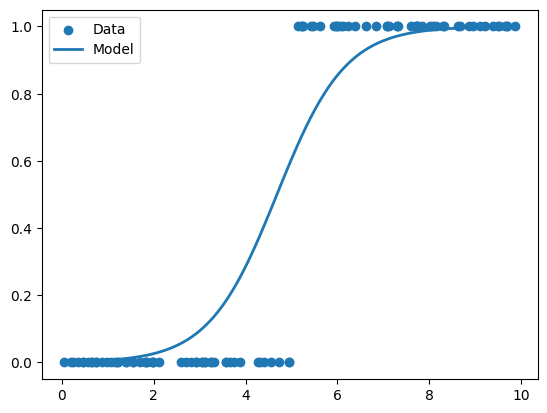

In [24]:
import matplotlib.pyplot as plt

# Scatter plot (actual data)
plt.scatter(X, y, label="Data")

# Create smooth X values
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# Predict using model
y_line = model._link(model.weights @ X_line.T  + model.bias)

# Plot line
plt.plot(X_line, y_line, label="Model", linewidth=2)

plt.legend()
plt.show()